In [53]:
# ATLAS v0

## LLM-Based Knowledge Extraction and Knowledge Graph Construction

In [55]:
# Imports

import networkx as nx
import matplotlib.pyplot as plt

from mistralai import Mistral

In [ ]:
# Initialize Mistral Client

from dotenv import load_dotenv
from mistralai import Mistral
import os

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")

client = Mistral(api_key=api_key)

In [57]:
# Data Models

from pydantic import BaseModel

class Entity(BaseModel):
    name: str
    type: str

class Relationship(BaseModel):
    source: str
    relation: str
    target: str

class ExtractionResult(BaseModel):
    entities: list[Entity]
    relationships: list[Relationship]

In [58]:
# Example Text

text = """
Microsoft invested in OpenAI.
OpenAI developed GPT-4.
AutoKaggle uses a Multi-Agent System.
AutoKaggle was evaluated on MLE-Bench.
"""

print(text)


Microsoft invested in OpenAI.
OpenAI developed GPT-4.
AutoKaggle uses a Multi-Agent System.
AutoKaggle was evaluated on MLE-Bench.



In [59]:
# Entity and Relationship Extraction Prompt

prompt = f"""
Extract entities and relationships from the following text.

Return ONLY valid JSON.

Schema:

{{
  "entities": [
    {{
      "name": "...",
      "type": "..."
    }}
  ],
  "relationships": [
    {{
      "source": "...",
      "relation": "...",
      "target": "..."
    }}
  ]
}}

Text:

{text}
"""

In [ ]:
# LLM-Based Knowledge Extraction

response = client.chat.complete(
    model="mistral-small-latest",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

raw_json = response.choices[0].message.content

print(raw_json)

```json
{
  "entities": [
    {
      "name": "Microsoft",
      "type": "Organization"
    },
    {
      "name": "OpenAI",
      "type": "Organization"
    },
    {
      "name": "GPT-4",
      "type": "Product"
    },
    {
      "name": "AutoKaggle",
      "type": "Product"
    },
    {
      "name": "Multi-Agent System",
      "type": "Technology"
    },
    {
      "name": "MLE-Bench",
      "type": "Benchmark"
    }
  ],
  "relationships": [
    {
      "source": "Microsoft",
      "relation": "invested_in",
      "target": "OpenAI"
    },
    {
      "source": "OpenAI",
      "relation": "developed",
      "target": "GPT-4"
    },
    {
      "source": "AutoKaggle",
      "relation": "uses",
      "target": "Multi-Agent System"
    },
    {
      "source": "AutoKaggle",
      "relation": "evaluated_on",
      "target": "MLE-Bench"
    }
  ]
}
```


In [61]:
# Parse LLM JSON Output

import json

clean_json = (
    raw_json
    .replace("```json", "")
    .replace("```", "")
    .strip()
)

data = json.loads(clean_json)

data

{'entities': [{'name': 'Microsoft', 'type': 'Organization'},
  {'name': 'OpenAI', 'type': 'Organization'},
  {'name': 'GPT-4', 'type': 'Product'},
  {'name': 'AutoKaggle', 'type': 'Product'},
  {'name': 'Multi-Agent System', 'type': 'Technology'},
  {'name': 'MLE-Bench', 'type': 'Benchmark'}],
 'relationships': [{'source': 'Microsoft',
   'relation': 'invested_in',
   'target': 'OpenAI'},
  {'source': 'OpenAI', 'relation': 'developed', 'target': 'GPT-4'},
  {'source': 'AutoKaggle', 'relation': 'uses', 'target': 'Multi-Agent System'},
  {'source': 'AutoKaggle', 'relation': 'evaluated_on', 'target': 'MLE-Bench'}]}

In [62]:
# Convert JSON Output to Pydantic Models

entities = [
    Entity(**entity)
    for entity in data["entities"]
]

relationships = [
    Relationship(**relationship)
    for relationship in data["relationships"]
]

result = ExtractionResult(
    entities=entities,
    relationships=relationships
)

result

ExtractionResult(entities=[Entity(name='Microsoft', type='Organization'), Entity(name='OpenAI', type='Organization'), Entity(name='GPT-4', type='Product'), Entity(name='AutoKaggle', type='Product'), Entity(name='Multi-Agent System', type='Technology'), Entity(name='MLE-Bench', type='Benchmark')], relationships=[Relationship(source='Microsoft', relation='invested_in', target='OpenAI'), Relationship(source='OpenAI', relation='developed', target='GPT-4'), Relationship(source='AutoKaggle', relation='uses', target='Multi-Agent System'), Relationship(source='AutoKaggle', relation='evaluated_on', target='MLE-Bench')])

In [ ]:
# Display Extraction Result

print("Entities:")
for entity in result.entities:
    print(f"- {entity.name} ({entity.type})")

print("\nRelationships:")
for rel in result.relationships:
    print(
        f"- {rel.source} --{rel.relation}--> {rel.target}"
    )

Entities:
- Microsoft (Organization)
- OpenAI (Organization)
- GPT-4 (Product)
- AutoKaggle (Product)
- Multi-Agent System (Technology)
- MLE-Bench (Benchmark)

Relationships:
- Microsoft --invested_in--> OpenAI
- OpenAI --developed--> GPT-4
- AutoKaggle --uses--> Multi-Agent System
- AutoKaggle --evaluated_on--> MLE-Bench


In [64]:
# Build Knowledge Graph

graph = nx.DiGraph()

for entity in result.entities:
    graph.add_node(
        entity.name,
        entity_type=entity.type
    )

for relation in result.relationships:
    graph.add_edge(
        relation.source,
        relation.target,
        relation=relation.relation
    )

In [65]:
# Graph Statistics

print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")

Nodes: 6
Edges: 4


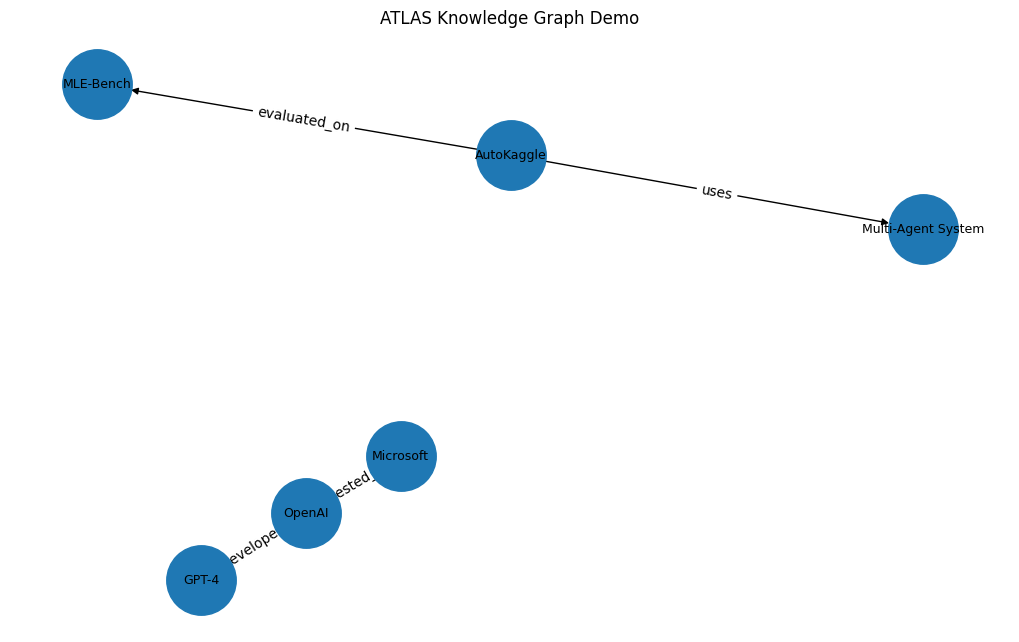

In [66]:
# Visualization

plt.figure(figsize=(10, 6))

pos = nx.spring_layout(
    graph,
    seed=42
)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

edge_labels = nx.get_edge_attributes(
    graph,
    "relation"
)

nx.draw_networkx_edge_labels(
    graph,
    pos,
    edge_labels=edge_labels
)

plt.title(
    "ATLAS Knowledge Graph Demo"
)

plt.show()

In [69]:
# Export Graph

import json
import networkx as nx

with open("graph.json", "w") as f:
    json.dump(
        nx.node_link_data(graph),
        f,
        indent=2
    )

In [71]:
nx.write_graphml(graph, "atlas_graph.graphml")

In [72]:
!ls

atlas_graph.graphml  graph.json  sample_data
